# Load Floating point Model
Load floating point model from the Drive

In [2]:
from tensorflow.keras.models import load_model
import os
from google.colab import drive

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the path where the model was saved in Google Drive
model_save_dir = '/content/drive/My Drive/LeNet-5'
model_load_path = os.path.join(model_save_dir, 'Models/lenet5_mnist_model.keras')

# Load the saved model
true_model = load_model(model_load_path)

# Print the summary of the loaded model to verify
true_model.summary()

print(f"LeNet-5 model loaded successfully from '{model_load_path}'.")

Mounted at /content/drive


Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,280 (520.63 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 88,854 (347.09 KB)

LeNet-5 model loaded successfully from '/content/drive/My Drive/LeNet-5/Models/lenet5_mnist_model.keras'.


# Quantization into Q4.3 signed
- write quantization function and test it
- quantize the model weight and save it
- compare the result between true model and quantized model

In [3]:
import numpy as np

def quantize_q4_3_signed(data):
    """
    Quantizes a matrix or vector to Q4.3 signed fixed-point representation.
    This interpretation implies 4 integer bits, 3 fractional bits, and 1 sign bit (total 8 bits).

    Range: [-2^4, 2^4 - 2^-3] = [-16, 15.875]
    LSB (quantization step): 2^-3 = 0.125

    Args:
        data (np.ndarray or float): The input matrix, vector, or scalar to quantize.

    Returns:
        np.ndarray or float: The quantized data.
    """
    fractional_bits = 3
    integer_bits = 4 # Excludes sign bit

    lsb = 2**(-fractional_bits) # 0.125
    max_val = (2**integer_bits) - lsb # 16 - 0.125 = 15.875
    min_val = -(2**integer_bits)    # -16

    # Convert to numpy array to handle both scalars and arrays
    data_np = np.asarray(data)

    # Scale the data to integer multiples of the LSB, round to nearest integer, then scale back
    # This effectively rounds to the nearest multiple of lsb
    quantized_data = np.round(data_np / lsb) * lsb

    # Clip values to the representable range
    quantized_data = np.clip(quantized_data, min_val, max_val)

    return quantized_data

# Test the function
print("--- Testing Q4.3 Signed Quantization ---")

# Test cases
test_values = [
    0.1,        # Positive, within range
    -0.5,       # Negative, within range
    1.23,       # Positive, needs rounding
    -2.78,      # Negative, needs rounding
    15.8,       # Close to max
    -15.9,      # Close to min
    16.5,       # Exceeds max, should be clipped to 15.875
    -17.2,      # Exceeds min, should be clipped to -16.0
    0.0,        # Zero
    0.06,       # Between 0 and 0.125, should round to 0
    0.13,       # Between 0.125 and 0.25, should round to 0.125
    -0.06,      # Between 0 and -0.125, should round to 0
    -0.13       # Between -0.125 and -0.25, should round to -0.125
]

print("\nScalar tests:")
for val in test_values:
    q_val = quantize_q4_3_signed(val)
    print(f"Original: {val:<8.4f}, Quantized: {q_val:<8.4f}")

print("\nVector test:")
vector = np.array([0.1, -0.5, 1.23, -2.78, 16.5, -17.2, 0.0])
q_vector = quantize_q4_3_signed(vector)
print("Original Vector:", vector)
print("Quantized Vector:", q_vector)

print("\nMatrix test:")
matrix = np.array([
    [0.1, -0.5, 1.23],
    [-2.78, 16.5, -17.2],
    [0.0, 0.06, 0.13]
])
q_matrix = quantize_q4_3_signed(matrix)
print("Original Matrix:\n", matrix)
print("Quantized Matrix:\n", q_matrix)

# Test with a known value and its expected quantized output
assert np.isclose(quantize_q4_3_signed(0.2), 0.250), "Test failed for 0.2"
assert np.isclose(quantize_q4_3_signed(0.1), 0.125), "Test failed for 0.1"
assert np.isclose(quantize_q4_3_signed(0.06), 0.0), "Test failed for 0.06"
assert np.isclose(quantize_q4_3_signed(16.5), 15.875), "Test failed for clipping max"
assert np.isclose(quantize_q4_3_signed(-17.2), -16.0), "Test failed for clipping min"
print("\nAssertion tests passed!")

--- Testing Q4.3 Signed Quantization ---

Scalar tests:
Original: 0.1000  , Quantized: 0.1250  
Original: -0.5000 , Quantized: -0.5000 
Original: 1.2300  , Quantized: 1.2500  
Original: -2.7800 , Quantized: -2.7500 
Original: 15.8000 , Quantized: 15.7500 
Original: -15.9000, Quantized: -15.8750
Original: 16.5000 , Quantized: 15.8750 
Original: -17.2000, Quantized: -16.0000
Original: 0.0000  , Quantized: 0.0000  
Original: 0.0600  , Quantized: 0.0000  
Original: 0.1300  , Quantized: 0.1250  
Original: -0.0600 , Quantized: -0.0000 
Original: -0.1300 , Quantized: -0.1250 

Vector test:
Original Vector: [  0.1   -0.5    1.23  -2.78  16.5  -17.2    0.  ]
Quantized Vector: [  0.125  -0.5     1.25   -2.75   15.875 -16.      0.   ]

Matrix test:
Original Matrix:
 [[  0.1   -0.5    1.23]
 [ -2.78  16.5  -17.2 ]
 [  0.     0.06   0.13]]
Quantized Matrix:
 [[  0.125  -0.5     1.25 ]
 [ -2.75   15.875 -16.   ]
 [  0.      0.      0.125]]

Assertion tests passed!


## Quantized Model Creation

In [6]:
import tensorflow as tf
import numpy as np

# Function to create a quantized model from an original model
def create_quantized_model(original_model, quantization_function, model_name):
    quantized_model = tf.keras.models.clone_model(original_model)
    quantized_model.set_weights(original_model.get_weights())

    # Iterate through layers and apply quantization to kernel weights
    for layer in quantized_model.layers:
        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
            original_weights = layer.get_weights()
            if original_weights:
                kernel_weights = original_weights[0]
                # Apply the quantization function element-wise
                quantized_kernel = np.array([quantization_function(w) for w in kernel_weights.flatten()]).reshape(kernel_weights.shape)

                # Reconstruct weights list: [quantized_kernel, bias] or just [quantized_kernel]
                if len(original_weights) > 1:
                    quantized_layer_weights = [quantized_kernel, original_weights[1]]
                else:
                    quantized_layer_weights = [quantized_kernel]
                layer.set_weights(quantized_layer_weights)
    print(f"Created {model_name} with quantized weights.")
    return quantized_model

# Create Q4.3 quantized model
quantized_model = create_quantized_model(true_model, quantize_q4_3_signed, "Q4.3 Signed Quantized Model")
quantized_model.summary()

Created Q4.3 Signed Quantized Model with quantized weights.


Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,280 (520.63 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 88,854 (347.09 KB)

## Quantized Model Saving

In [9]:
import os
from google.colab import drive

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the path to save the model and data in Google Drive
model_save_dir = '/content/drive/My Drive/LeNet-5'
# Ensure the base directory exists
os.makedirs(model_save_dir, exist_ok=True)

quantized_model_save_path = os.path.join(model_save_dir, 'Model/lenet5_mnist_model_q4_3.keras')

# Ensure the full directory path for the model file exists
os.makedirs(os.path.dirname(quantized_model_save_path), exist_ok=True)

# Save the model
quantized_model.save(quantized_model_save_path)
print(f"LeNet-5 model saved successfully to '{quantized_model_save_path}' (Keras v3 format).")

Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,280 (520.63 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 88,854 (347.09 KB)

LeNet-5 model saved successfully to '/content/drive/My Drive/LeNet-5/Model/lenet5_mnist_model_q4_3.keras' (Keras v3 format).


## Quantized Model Accaurcy

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original x_test shape: (10000, 28, 28)
Original y_test shape: (10000,)
Processed x_test shape: (10000, 28, 28, 1)
Processed y_test shape: (10000, 10)
MNIST test dataset loaded and preprocessed successfully.
Evaluating the original (unquantized) model...
Original Model Test Loss:     0.0351
Original Model Test Accuracy: 99.09%
Evaluating the Quantized model...
Quantized Model Test Loss:     0.0497
Quantized Model Test Accuracy: 98.50%

--- Model Accuracy Comparison ---
Original Model Accuracy: 99.09%
Q4.3 signed Model Accuracy: 98.50%
---------------------------------


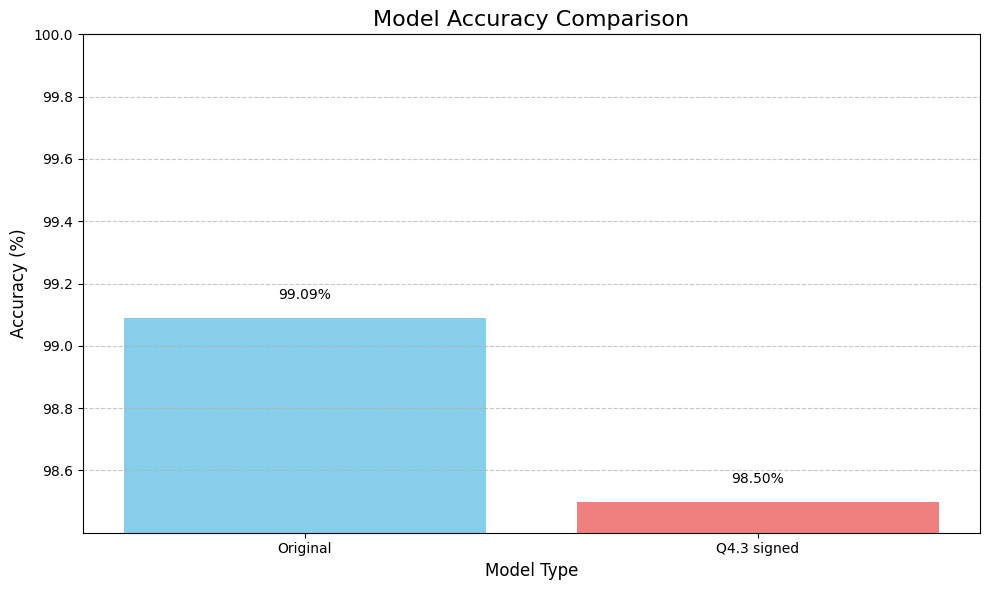

Accuracy comparison and plot generated successfully.


In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the MNIST test dataset
(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Original x_test shape: {x_test.shape}")
print(f"Original y_test shape: {y_test.shape}")

# 2. Preprocess the test images
# Normalize pixel values to the range [0, 1]
x_test = x_test.astype('float32') / 255.0

# Reshape images to add a channel dimension (for grayscale, it's 1 channel)
# LeNet-5 expects input shape (batch_size, height, width, channels)
x_test = np.expand_dims(x_test, -1)

# One-hot encode the labels
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

print(f"Processed x_test shape: {x_test.shape}")
print(f"Processed y_test shape: {y_test.shape}")
print("MNIST test dataset loaded and preprocessed successfully.")

# ---- True Model Accuarcy ----
print("Evaluating the original (unquantized) model...")

# Evaluate the original model on the test data
loss_original, accuracy_original = true_model.evaluate(x_test, y_test, verbose=0)

print(f"Original Model Test Loss:     {loss_original:.4f}")
print(f"Original Model Test Accuracy: {accuracy_original*100:.2f}%")

# ---- Quantized Model Accuarcy ----
print("Evaluating the Quantized model...")

# Evaluate the original model on the test data
loss_quantized, accuracy_quantized = quantized_model.evaluate(x_test, y_test, verbose=0)

print(f"Quantized Model Test Loss:     {loss_quantized:.4f}")
print(f"Quantized Model Test Accuracy: {accuracy_quantized*100:.2f}%")

# ----------- Ploting ----------------
# 1. Store the accuracy scores in a dictionary
accuracies = {
    'Original': accuracy_original,
    'Q4.3 signed': accuracy_quantized
}

# 2. Print a clear comparison of the accuracies
print("\n--- Model Accuracy Comparison ---")
for model_type, accuracy in accuracies.items():
    print(f"{model_type} Model Accuracy: {accuracy*100:.2f}%")
print("---------------------------------")

# 3. Prepare data for plotting
model_names = list(accuracies.keys())
accuracy_values = [accuracy * 100 for accuracy in accuracies.values()]

# 4. Create a bar plot to visualize the accuracy comparison
plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracy_values, color=['skyblue', 'lightcoral', 'lightgreen'])

# Add title and labels
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Model Type', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)

# Set y-axis limit to emphasize differences
plt.ylim(min(accuracy_values) - 0.1, 100.0) # Adjust min value slightly below lowest accuracy

# Display accuracy values on top of each bar
for i, value in enumerate(accuracy_values):
    plt.text(i, value + 0.05, f'{value:.2f}%', ha='center', va='bottom', fontsize=10)

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Accuracy comparison and plot generated successfully.")

# Model Probing
- divide the model to extract the feature map and weights
- save the weights
- save the feature map for Test [0..9]


In [15]:
import numpy as np
import os
from google.colab import drive

def save_quantized_array_to_files(flat_array, file_name, n_bits, output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights'):
    """
    Saves a numpy array (assumed to contain scaled floating-point values representing
    fixed-point numbers) to a CSV file and a .mem file (in hexadecimal integer format).

    Args:
        array_input (np.ndarray,list): The numpy array of scaled floating-point values.
                                 This array will be flattened before saving.
        file_name (str): The base name for the output files (e.g., "feature_map_1").
        n_bits (int): The number of fractional bits (n) used in the Q4.n format. This is used for scaling to integer representation.
        output_base_dir (str): The base directory in Google Drive to save the files.
                               Defaults to '/content/drive/My Drive/LeNet-5/Quantized_Weights'.
    """
    # Mount Google Drive if not already mounted
    if not os.path.exists('/content/drive'):
        print("Mounting Google Drive...")
        drive.mount('/content/drive')

    # Ensure the output directory exists
    os.makedirs(output_base_dir, exist_ok=True)

    # Flatten the array to 1D
    flat_array = np.array(flat_array)
    # Scaling Factor
    scaling_factor = 2**n_bits

    # --- Save to CSV ---
    csv_file_path = os.path.join(output_base_dir, f"{file_name}.csv")
    np.savetxt(csv_file_path, flat_array, delimiter=",", fmt='%.8f')
    print(f"Saved CSV file to: {csv_file_path}")

    # --- Save to MEM (hexadecimal integer format) ---
    mem_file_path = os.path.join(output_base_dir, f"{file_name}.mem")

    # Convert floats back to their integer fixed-point representation.
    # Then explicitly cast to 8-bit unsigned integer type as requested for the memory file format.
    # This handles both signed (two's complement) and unsigned 8-bit values,
    # mapping signed negative values to their unsigned 8-bit representation (e.g., -128 -> 128, -1 -> 255).
    # Values outside the 8-bit unsigned range (0-255) will be clipped implicitly by np.uint8.
    fixed_point_integers_8bit = np.round(flat_array * scaling_factor).astype(np.uint8)

    # For 8-bit output, we always need 2 hexadecimal digits.
    hex_format_string = "02X"

    with open(mem_file_path, 'w') as f:
        for val in fixed_point_integers_8bit:
            f.write(f"{val:{hex_format_string}}\n")
    print(f"Saved MEM file to: {mem_file_path}")

print("Function 'save_quantized_array_to_files' defined.")

# Example usage
file_name = f"Test"
array = np.array([1.2,3.5622,2.866,0.213,1.33])
output_path = "/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed"
# Assuming n_bits=4 for Q4.4, resulting in values that *could* fit within 8 bits
# The output for the .mem file will now always be forced to 8-bit unsigned hex.
save_quantized_array_to_files(array, file_name, n_bits = 4,output_base_dir= output_path)

Function 'save_quantized_array_to_files' defined.
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/Test.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/Test.mem


## Weight Extraction

### Conv1,2 Layers

In [ ]:
# # Weights/Bais conv1
# conv1_weight = quantized_model.layers[0].get_weights()[0]
# conv1_bias = quantized_model.layers[0].get_weights()[1]
# print(f"Shape of Conv1 weight = {conv1_weight.shape}")

# for i in range(conv1_weight.shape[3]):
#     # The third dimension (axis 2) of conv1_weight is the input channel and has size 1.
#     # So, we should access index 0, not 1.
#     # For the print statement and data extraction, use index 0 for the third axis.

#     print(f"Unflat Feature Map {i} (First Channel, shape {conv1_weight[:, :, 0, i].shape})")

#     # Feature Map 1 Parts - Corrected to access index 0 for the input channel
#     conv1_weight_parts = conv1_weight[:, :, 0, i]

#     # Flatten the weight parts
#     flatted_conv1_weight = conv1_weight_parts.flatten()

#     # Quantize the flattened weights using quantize_q07
#     # The original code was incorrectly using quantize_q07 on 'flatted_Feature_Map_2'
#     # which is a feature map, not the weights being processed in this loop.
#     flatted_conv1_weight = quantize_q4_3_signed(flatted_conv1_weight)

#     # Save the quantized conv1 weights.
#     # The original code was incorrectly saving 'flatted_predictions'.
#     save_quantized_array_to_files(flatted_conv1_weight, f"conv1_weights_filter_{i+1}", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/conv1')


# print(f"Shape of Conv1 bais = {conv1_bias.shape}")

# flatted_conv1_bias = quantize_q4_3_signed(conv1_bias).flatten()
# save_quantized_array_to_files(flatted_conv1_bias, f"conv1_bais", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/conv1')

# # Weights/Bais conv2
# conv2_weight = model.layers[2].get_weights()[0]
# conv2_bias = model.layers[2].get_weights()[1]
# print(f"Shape of Conv2 weight = {conv2_weight.shape}")

# for i in range(conv2_weight.shape[2]):
#   for j in range(conv2_weight.shape[3]):
#       # The third dimension (axis 2) of conv1_weight is the input channel and has size 1.
#       # So, we should access index 0, not 1.
#       # For the print statement and data extraction, use index 0 for the third axis.

#       print(f"For Feature Map {i}:Unflat Weight {j} ({i} Channel, shape {conv2_weight[:, :, i, j].shape})")

#       # Feature Map 1 Parts - Corrected to access index 0 for the input channel
#       conv2_weight_parts = conv2_weight[:, :, i, j]

#       # Flatten the weight parts
#       flatted_conv2_weight = conv2_weight_parts.flatten()

#       # Quantize the flattened weights using quantize_q07
#       # The original code was incorrectly using quantize_q07 on 'flatted_Feature_Map_2'
#       # which is a feature map, not the weights being processed in this loop.
#       flatted_conv2_weight = quantize_q07(flatted_conv2_weight)

#       # Save the quantized conv1 weights.
#       # The original code was incorrectly saving 'flatted_predictions'.
#       save_quantized_array_to_files(flatted_conv2_weight, f"conv2_weights_Channel{i+1}_filter_{j+1}", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/conv2')


# print(f"Shape of Conv2 bais = {conv2_bias.shape}")

# flatted_conv2_bias = quantize_q07(conv2_bias).flatten()
# save_quantized_array_to_files(flatted_conv2_bias, f"conv2_bais", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/conv2')


### dense 1,2,3 Layers

In [16]:
# Weights/Bais Dense 1
dense1_weight = quantized_model.layers[5].get_weights()[0]
dense1_bias = quantized_model.layers[5].get_weights()[1]
print(f"Shape of dense1 weight = {dense1_weight.shape}")
flatted_dense1_weight = quantize_q4_3_signed(dense1_weight).flatten()
save_quantized_array_to_files(flatted_dense1_weight, f"dense1_weight", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense1')

print(f"Shape of dense1 bais = {dense1_bias.shape}")
flatted_dense1_bias = quantize_q4_3_signed(dense1_bias).flatten()
save_quantized_array_to_files(flatted_dense1_bias, f"dense1_bias", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense1')

# Weights/Bais Dense 2
dense2_weight = quantized_model.layers[6].get_weights()[0]
dense2_bias = quantized_model.layers[6].get_weights()[1]
print(f"Shape of dense2 weight = {dense2_weight.shape}")
flatted_dense2_weight = quantize_q4_3_signed(dense2_weight).flatten()
save_quantized_array_to_files(flatted_dense2_weight, f"dense2_weight", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense2')

print(f"Shape of dense2 bais = {dense2_bias.shape}")
flatted_dense2_bias = quantize_q4_3_signed(dense2_bias).flatten()
save_quantized_array_to_files(flatted_dense2_bias, f"dense2_bias", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense2')

# Weights/Bais Dense 3
dense3_weight = quantized_model.layers[7].get_weights()[0]
dense3_bias = quantized_model.layers[7].get_weights()[1]
print(f"Shape of dense3 weight = {dense3_weight.shape}")
flatted_dense3_weight = quantize_q4_3_signed(dense3_weight).flatten()
save_quantized_array_to_files(flatted_dense3_weight, f"dense3_weight", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense3')

print(f"Shape of dense3 bais = {dense3_bias.shape}")
flatted_dense3_bias = quantize_q4_3_signed(dense3_bias).flatten()
save_quantized_array_to_files(flatted_dense3_bias, f"dense3_bias", n_bits=0,output_base_dir='/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense3')

Shape of dense1 weight = (256, 120)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense1/dense1_weight.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense1/dense1_weight.mem
Shape of dense1 bais = (120,)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense1/dense1_bias.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense1/dense1_bias.mem
Shape of dense2 weight = (120, 84)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense2/dense2_weight.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense2/dense2_weight.mem
Shape of dense2 bais = (84,)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/weights/dense2/dense2_bias.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_sign

## Create a probed Model

In [12]:
import tensorflow as tf

def create_feature_extractor_models(original_model, target_layer_name):
    """
    Creates three models for a given target layer:
    1. Input Extractor Model: All layers before the target layer.
    2. Target Layer Model: The target layer itself.
    3. Remaining Model: All layers after the target layer.

    Args:
        original_model (tf.keras.Model): The complete original model.
        target_layer_name (str): The name of the layer to extract.

    Returns:
        tuple: (input_extractor_model, target_layer_model, remaining_model)
    """
    # Find the target layer and its index
    target_layer = None
    target_layer_index = -1
    for i, layer in enumerate(original_model.layers):
        if layer.name == target_layer_name:
            target_layer = layer
            target_layer_index = i
    if target_layer is None:
        raise ValueError(f"Target layer '{target_layer_name}' not found in the model.")

    # 1. Create Input Extractor Model
    # This model will output the input to our target layer
    if target_layer_index == 0:
        # If target layer is the first layer, input_extractor_model is not applicable
        input_extractor_model = None
        input_to_target_layer_output = original_model.layers[0].input
    else:
        input_to_target_layer = original_model.layers[target_layer_index - 1].output
        # Ensure the model is built before accessing original_model.inputs
        if not original_model.built:
            original_model.build(input_shape=(None, 28, 28, 1)) # Assuming LeNet-5 input shape
        input_extractor_model = tf.keras.Model(inputs=original_model.inputs, outputs=input_to_target_layer,name = f"{target_layer_name}_input_extractor_model")
        input_to_target_layer_output = input_extractor_model.output

    # 2. Create Target Layer Model
    # This model takes the output of the input_extractor_model as its input
    target_layer_input_shape = target_layer.input.shape
    # Handle cases where input_shape might be (None, H, W, C) for the batch dimension
    if isinstance(target_layer_input_shape, list): # For models with multiple inputs
        # Assuming a single input for simplicity in this LeNet-5 context
        target_layer_input_shape = target_layer_input_shape[0]
    # Create a dummy input tensor with batch dimension set to None
    target_layer_input_tensor = tf.keras.Input(shape=target_layer_input_shape[1:])
    target_layer_output_tensor = target_layer(target_layer_input_tensor)
    target_layer_model = tf.keras.Model(inputs=target_layer_input_tensor, outputs=target_layer_output_tensor, name=f"{target_layer_name}_model")
    target_layer_model.set_weights(target_layer.get_weights())


    # 3. Create Remaining Model
    # This model takes the output of the target layer as its input
    if target_layer_index == len(original_model.layers) - 1:
      # If target layer is the last layer, remaining_model is not applicable
      remaining_model = None
    else:
      # Create a new input tensor for the 'remaining' part of the model
      remaining_input_tensor = tf.keras.Input(shape=target_layer.output.shape[1:])
      x = remaining_input_tensor
      for i in range(target_layer_index + 1, len(original_model.layers)):
          layer = original_model.layers[i]
          x = layer(x)
      remaining_model = tf.keras.Model(inputs=remaining_input_tensor, outputs=x, name=f"remaining_after_{target_layer_name}_model")

    return input_extractor_model, target_layer_model, remaining_model

#-------------- Quantized Model ------------------
print("Creating a Probed Quauntization Model")
### testing the model
conv1poo1_model, conv2_model,_ = create_feature_extractor_models(quantized_model,"conv2")
_,pool2_model,_    = create_feature_extractor_models(quantized_model,"pool2")
_,flatten_mdoel,_  = create_feature_extractor_models(quantized_model,"flatten")
_,dense1_model,_   = create_feature_extractor_models(quantized_model,"dense1")
_,dense2_model,out_model = create_feature_extractor_models(quantized_model,"dense2")
print("Probed Quantization Model is Created")


Creating a Probed Quauntization Model
Probed Quantization Model is Created


## Test Creation

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# Lists to store images and true labels for known tests
index_dic = {
    0:5942,
    1:9345,
    2:8683,
    3:4940,
    4:6369,
    5:3028,
    6:1688,
    7:4471,
    8:8932,
    9:5042
}

test_images_list = []
test_image_labels = []

print("Generating test images based on index_dic...")

# Iterate through the index_dic to get specific test images
for digit, index_val in index_dic.items():
    # Get the test image and its true label using the index from index_dic
    random_image = x_test[index_val]
    true_label_one_hot = y_test[index_val]
    true_label = np.argmax(true_label_one_hot)

    # The model expects a batch of images, so add a batch dimension
    image_for_prediction = np.expand_dims(random_image, axis=0)

    # Store the image and true label
    test_images_list.append(image_for_prediction)
    test_image_labels.append(true_label)

    # Optionally, display the image and its label for verification
    # plt.imshow(random_image.squeeze(), cmap='gray')
    # plt.title(f"Digit: {digit}, True Label: {true_label}")
    # plt.axis('off')
    # plt.show()

print(f"Generated {len(test_images_list)} test images for known digits 0-9.")
print(f"First image shape: {test_images_list[0].shape}")
print(f"True labels for generated images: {test_image_labels}")

Generating test images based on index_dic...
Generated 10 test images for known digits 0-9.
First image shape: (1, 28, 28, 1)
True labels for generated images: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


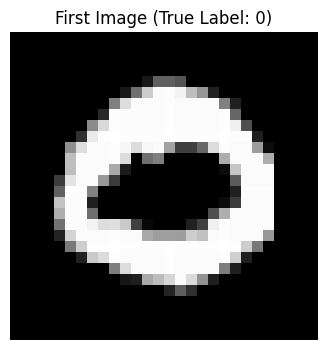

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# Get the first image from the list
first_image_batch = test_images_list[0]

# Remove the batch dimension and channel dimension if it's grayscale
first_image = first_image_batch.squeeze()

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(first_image, cmap='gray')
plt.title(f'First Image (True Label: {test_image_labels[0]})')
plt.axis('off')
plt.show()

## Parameter Extraction for test

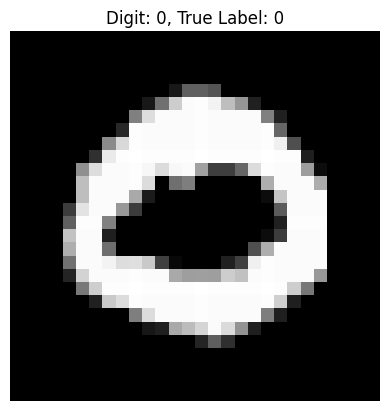

Prediction Probabilities: [[6.9683731e-02 4.7305057e-05 4.3053122e-04 2.4274054e-04 5.5607542e-04
  5.5292827e-01 2.0653538e-03 8.9049700e-04 1.6229608e-06 3.7315381e-01]]
True Label: 0
Predicted Class: 5
Shape of Image: (1, 28, 28, 1)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/0/Image/Image.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/0/Image/Image.mem
Shape of Feature Map 2: (1, 4, 4, 16)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/0/FM_2/_flatten_FM2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/0/FM_2/_flatten_FM2.mem
Shape of Feature Map 3: (1, 120)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/0/FM_3/Feature_Map_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/0/FM_3/Feature_Map_3.mem
Shape of Feature Map 4: (1, 84)
Saved CSV file to: /content/drive/My Driv

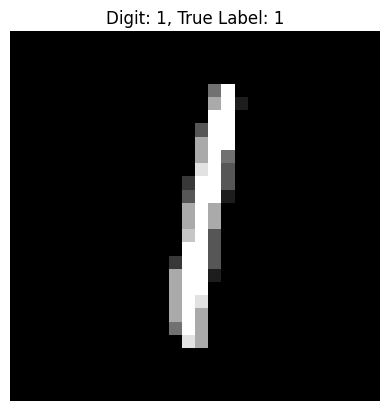

Prediction Probabilities: [[4.4057560e-11 9.9999583e-01 3.3441225e-08 5.7022052e-13 2.3349799e-07
  1.2988822e-09 1.0979573e-09 3.7179368e-06 2.2091380e-07 6.4770549e-09]]
True Label: 1
Predicted Class: 1
Shape of Image: (1, 28, 28, 1)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/1/Image/Image.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/1/Image/Image.mem
Shape of Feature Map 2: (1, 4, 4, 16)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/1/FM_2/_flatten_FM2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/1/FM_2/_flatten_FM2.mem
Shape of Feature Map 3: (1, 120)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/1/FM_3/Feature_Map_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/1/FM_3/Feature_Map_3.mem
Shape of Feature Map 4: (1, 84)
Saved CSV file to: /content/drive/My Driv

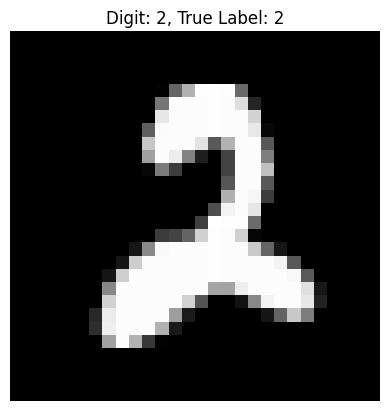

Prediction Probabilities: [[8.36430664e-12 1.23649171e-08 1.00000000e+00 1.81022156e-10
  2.44150674e-13 1.13067975e-13 1.29350452e-14 3.76227893e-09
  2.66589293e-08 8.34540588e-16]]
True Label: 2
Predicted Class: 2
Shape of Image: (1, 28, 28, 1)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/2/Image/Image.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/2/Image/Image.mem
Shape of Feature Map 2: (1, 4, 4, 16)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/2/FM_2/_flatten_FM2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/2/FM_2/_flatten_FM2.mem
Shape of Feature Map 3: (1, 120)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/2/FM_3/Feature_Map_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/2/FM_3/Feature_Map_3.mem
Shape of Feature Map 4: (1, 84)
Saved CSV file to: /content/d

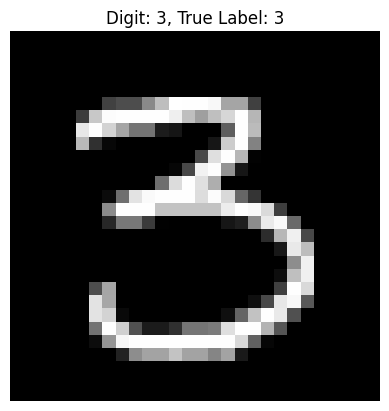

Prediction Probabilities: [[5.8762585e-14 1.3170440e-09 2.3603091e-09 1.0000000e+00 2.1436652e-13
  1.7745505e-08 6.6664322e-12 1.0394342e-09 1.7222831e-09 6.5583200e-13]]
True Label: 3
Predicted Class: 3
Shape of Image: (1, 28, 28, 1)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/3/Image/Image.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/3/Image/Image.mem
Shape of Feature Map 2: (1, 4, 4, 16)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/3/FM_2/_flatten_FM2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/3/FM_2/_flatten_FM2.mem
Shape of Feature Map 3: (1, 120)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/3/FM_3/Feature_Map_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/3/FM_3/Feature_Map_3.mem
Shape of Feature Map 4: (1, 84)
Saved CSV file to: /content/drive/My Driv

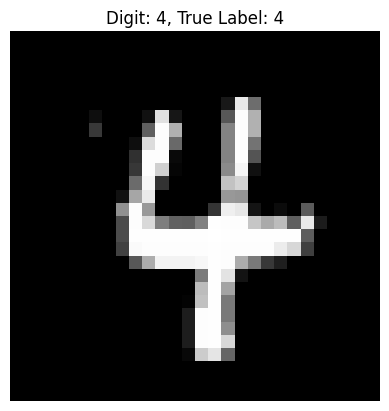

Prediction Probabilities: [[3.7165828e-16 3.5622744e-11 4.4567815e-11 2.0422872e-13 1.0000000e+00
  1.6261686e-12 1.6417439e-13 6.5642656e-09 1.2485156e-13 6.3783118e-11]]
True Label: 4
Predicted Class: 4
Shape of Image: (1, 28, 28, 1)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/4/Image/Image.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/4/Image/Image.mem
Shape of Feature Map 2: (1, 4, 4, 16)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/4/FM_2/_flatten_FM2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/4/FM_2/_flatten_FM2.mem
Shape of Feature Map 3: (1, 120)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/4/FM_3/Feature_Map_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/4/FM_3/Feature_Map_3.mem
Shape of Feature Map 4: (1, 84)
Saved CSV file to: /content/drive/My Driv

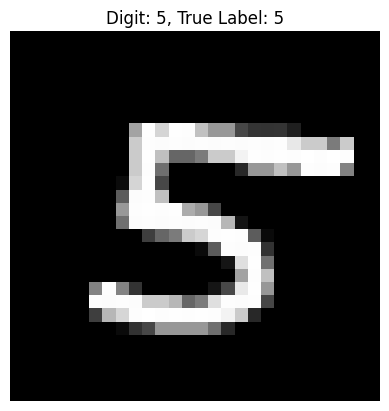

Prediction Probabilities: [[1.3808292e-17 1.0105037e-14 2.9104560e-15 1.5700534e-10 2.4446726e-19
  1.0000000e+00 5.2172668e-15 6.3449279e-16 9.6126977e-14 1.6010390e-09]]
True Label: 5
Predicted Class: 5
Shape of Image: (1, 28, 28, 1)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/5/Image/Image.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/5/Image/Image.mem
Shape of Feature Map 2: (1, 4, 4, 16)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/5/FM_2/_flatten_FM2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/5/FM_2/_flatten_FM2.mem
Shape of Feature Map 3: (1, 120)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/5/FM_3/Feature_Map_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/5/FM_3/Feature_Map_3.mem
Shape of Feature Map 4: (1, 84)
Saved CSV file to: /content/drive/My Driv

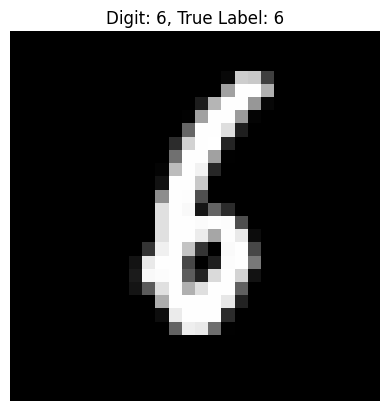

Prediction Probabilities: [[5.8895520e-09 3.9302379e-09 2.8017035e-09 9.8436962e-12 6.7606010e-09
  1.1865621e-06 9.9999881e-01 9.4742443e-13 3.9181671e-08 3.0266436e-09]]
True Label: 6
Predicted Class: 6
Shape of Image: (1, 28, 28, 1)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/6/Image/Image.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/6/Image/Image.mem
Shape of Feature Map 2: (1, 4, 4, 16)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/6/FM_2/_flatten_FM2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/6/FM_2/_flatten_FM2.mem
Shape of Feature Map 3: (1, 120)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/6/FM_3/Feature_Map_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/6/FM_3/Feature_Map_3.mem
Shape of Feature Map 4: (1, 84)
Saved CSV file to: /content/drive/My Driv

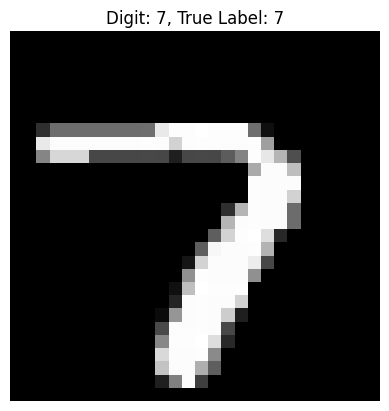

Prediction Probabilities: [[2.2332609e-12 6.7072409e-10 4.6272373e-07 1.2446425e-06 2.4082364e-12
  6.7929828e-11 5.3716363e-13 9.9999833e-01 4.6025883e-12 9.7459996e-09]]
True Label: 7
Predicted Class: 7
Shape of Image: (1, 28, 28, 1)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/7/Image/Image.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/7/Image/Image.mem
Shape of Feature Map 2: (1, 4, 4, 16)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/7/FM_2/_flatten_FM2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/7/FM_2/_flatten_FM2.mem
Shape of Feature Map 3: (1, 120)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/7/FM_3/Feature_Map_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/7/FM_3/Feature_Map_3.mem
Shape of Feature Map 4: (1, 84)
Saved CSV file to: /content/drive/My Driv

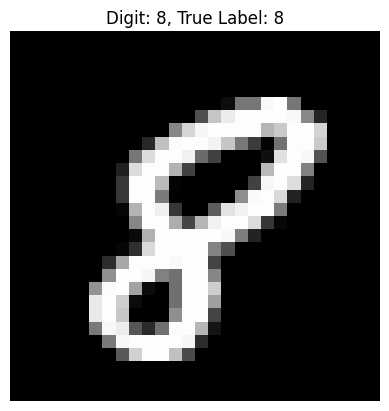

Prediction Probabilities: [[8.88985066e-14 2.36969255e-12 1.00718323e-09 1.72462760e-12
  1.40279574e-14 1.39485775e-11 3.20991673e-14 7.80790841e-16
  1.00000000e+00 9.21473939e-11]]
True Label: 8
Predicted Class: 8
Shape of Image: (1, 28, 28, 1)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/8/Image/Image.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/8/Image/Image.mem
Shape of Feature Map 2: (1, 4, 4, 16)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/8/FM_2/_flatten_FM2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/8/FM_2/_flatten_FM2.mem
Shape of Feature Map 3: (1, 120)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/8/FM_3/Feature_Map_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/8/FM_3/Feature_Map_3.mem
Shape of Feature Map 4: (1, 84)
Saved CSV file to: /content/d

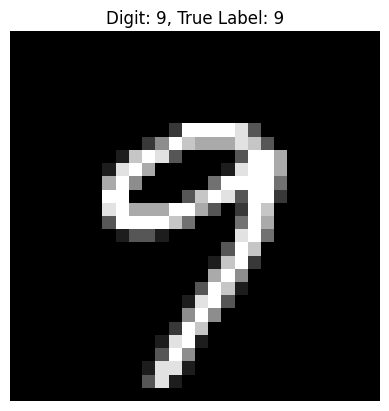

Prediction Probabilities: [[6.2214027e-12 3.7159529e-09 1.4038914e-10 6.7217053e-07 1.9884924e-07
  1.0827915e-08 6.2737562e-14 5.1687329e-07 1.4590289e-09 9.9999857e-01]]
True Label: 9
Predicted Class: 9
Shape of Image: (1, 28, 28, 1)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/9/Image/Image.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/9/Image/Image.mem
Shape of Feature Map 2: (1, 4, 4, 16)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/9/FM_2/_flatten_FM2.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/9/FM_2/_flatten_FM2.mem
Shape of Feature Map 3: (1, 120)
Saved CSV file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/9/FM_3/Feature_Map_3.csv
Saved MEM file to: /content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/9/FM_3/Feature_Map_3.mem
Shape of Feature Map 4: (1, 84)
Saved CSV file to: /content/drive/My Driv

In [95]:
# Make a prediction using the model
for digit in range(10):
  test_image = test_images_list[digit]
  true_label = test_image_labels[digit]
  # Add a batch dimension to the single image
  Feature_Map_1 = conv1poo1_model.predict(test_image, verbose=0)
  Feature_Map_1 = quantize_q4_3_signed(Feature_Map_1)

  connect_FM_1  = conv2_model.predict(Feature_Map_1, verbose=0)
  Feature_Map_2 = pool2_model.predict(connect_FM_1, verbose=0)
  Feature_Map_2 = quantize_q4_3_signed(Feature_Map_2)

  connect_FM_2  = flatten_mdoel.predict(Feature_Map_2, verbose=0)
  Feature_Map_3 = dense1_model.predict(connect_FM_2, verbose=0)
  Feature_Map_3 = quantize_q4_3_signed(Feature_Map_3)

  Feature_Map_4  = dense2_model.predict(Feature_Map_3, verbose=0)
  Feature_Map_4  = quantize_q4_3_signed(Feature_Map_4)

  predictions = out_model.predict(Feature_Map_4, verbose=0)
  predicted_class = np.argmax(predictions)

  # Display the image and prediction
  plt.imshow(test_image.squeeze(), cmap='gray')
  plt.title(f"Digit: {digit}, True Label: {true_label}")
  plt.axis('off')
  plt.show()
  print(f"Prediction Probabilities: {predictions}")
  print(f"True Label: {true_label}")
  print(f"Predicted Class: {predicted_class}")

  # Image
  print(f"Shape of Image: {image_for_prediction.shape}")
  image_save_dir = f'/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/{digit}/Image/'
  os.makedirs(image_save_dir, exist_ok=True) # Ensure the directory exists
  image_file_path = os.path.join(image_save_dir, 'image_for_prediction.png')
  plt.imsave(image_file_path,test_image.squeeze(), cmap='gray')
  flatted_image = image_for_prediction.flatten()
  save_quantized_array_to_files(flatted_image,f"Image", n_bits=0,output_base_dir= image_save_dir)

  # # Feature Map 1
  # print(f"Shape of Feature Map 1: {Feature_Map_1.shape}")

  # for i in range(Feature_Map_1.shape[3]):
  #     # Feature_Map [Weights = 0 , Bais = 1] [Filter Demensions]
  #     flatted_Feature_Map_1_parts = [] # Use a list to collect parts

  #     # The original code's intent for Feature_Map_1[0][:][:][0] was likely to show the first channel.
  #     # Feature_Map_1[0, :, :, 0] extracts the 2D data for the first channel (shape: 12x12).
  #     print(f"Unflat Feature Map {i} (First Channel, shape {Feature_Map_1[0, :, :, i].shape})")
  #     # print(Feature_Map_1[0][:][:][i]) # Print the first channel for better understanding

  #     # Feature Map 1 Parts
  #     Feature_Map_1_parts = Feature_Map_1[0][:][:][i]
  #     # Concatenate all collected parts into a single 1D array
  #     flatted_Feature_Map_1 = Feature_Map_1_parts.flatten()
  #     flatted_Feature_Map_1 = quantize_q4_3_signed(flatted_Feature_Map_1)

  #     save_quantized_array_to_files(flatted_Feature_Map_1,f"Feature_Map_1_Filter_{i+1}", n_bits=4,output_base_dir=f'/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/{digit}/FM_1')

  # Feature Map 2
  print(f"Shape of Feature Map 2: {Feature_Map_2.shape}")
  flatted_Feature_Map_2_total = quantize_q4_3_signed(connect_FM_2).flatten()
  save_quantized_array_to_files(flatted_Feature_Map_2_total,f"_flatten_FM2", n_bits=4,output_base_dir=f'/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/{digit}/FM_2')

  # for i in range(Feature_Map_2.shape[3]):
  #     # Feature_Map [Weights = 0 , Bais = 1] [Filter Demensions]
  #     flatted_Feature_Map_2_parts = [] # Use a list to collect parts

  #     # The original code's intent for Feature_Map_1[0][:][:][0] was likely to show the first channel.
  #     # Feature_Map_1[0, :, :, 0] extracts the 2D data for the first channel (shape: 12x12).
  #     print(f"Unflat Feature Map {i} (First Channel, shape {Feature_Map_2[0, :, :, i].shape})")
  #     # print(Feature_Map_1[0][:][:][i]) # Print the first channel for better understanding

  #     # Feature Map 1 Parts
  #     Feature_Map_2_parts = Feature_Map_2[0, :, :, i]
  #     # Concatenate all collected parts into a single 1D array
  #     flatted_Feature_Map_2 = Feature_Map_2_parts.flatten()
  #     flatted_Feature_Map_2 = quantize_q4_3_signed(flatted_Feature_Map_2)

  #     save_quantized_array_to_files(flatted_Feature_Map_2,f"Feature_Map_2_Filter_{i+1}", n_bits=4,output_base_dir=f'/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/{digit}/FM_2')
  # Feature Map 3
  print(f"Shape of Feature Map 3: {Feature_Map_3.shape}")

  flatted_Feature_Map_3 = quantize_q4_3_signed(Feature_Map_3).flatten()
  save_quantized_array_to_files(flatted_Feature_Map_3,f"Feature_Map_3", n_bits=4,output_base_dir=f'/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/{digit}/FM_3')

  # Feature Map 4
  print(f"Shape of Feature Map 4: {Feature_Map_4.shape}")

  flatted_Feature_Map_4 = quantize_q4_3_signed(Feature_Map_4).flatten()
  save_quantized_array_to_files(flatted_Feature_Map_4,f"Feature_Map_4", n_bits=4,output_base_dir=f'/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/{digit}/FM_4')

  # predictions
  print(f"Shape of predictions: {predictions.shape}")

  flatted_predictions = quantize_q4_3_signed(predictions).flatten()
  save_quantized_array_to_files(flatted_predictions,f"Predictions", n_bits=4,output_base_dir=f'/content/drive/My Drive/LeNet-5/Quantized_Weights/Q4_3_signed/{digit}/Predication')